# Dataset Analysis

In this notebook we make general analysis of the dataset.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from workspace.sources.local_datasets.dataset import Dataset
from workspace.sources.local_datasets.data.utils import plot_token_length_distribution, plot_label_distribution, \
    plot_article_length_distribution
from workspace.sources.local_datasets.preprocessing.tokenization import NLTKTokenizer, BERTTokenizer, GPT1_Tokenizer

rd_seed = 42
dataset_name = 'ISOT'
dataset_path = 'isot.csv'

### First Look

In [12]:
df = pd.read_csv(dataset_path)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   article  10000 non-null  object
 1   label    10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


,article,label
0,Heaven’s Gatekeeper? Jesse Jackson Proclaims T...,0
1,Obama And Justin Trudeau Had Dinner Tuesday; ...,0
2,"U.S. willing, if asked, to facilitate talks be...",1
3,Elysee plays down opulence of Macron birthday ...,1
4,CNN Anchor Asks Van Jones To Take Back His Pra...,0


In [13]:
df['article'].iloc[0]

'Heaven’s Gatekeeper? Jesse Jackson Proclaims That Trump ‘Would Not Qualify to Get Into Jesus’ Kingdom’ Jesse Jackson thinks he s Heaven s gatekeeper The arrogant  reverend  proclaimed that President Trump might not qualify to enter Jesus  Kingdom. How dare he!Jackson made the comments at the  Ministers March for Justice :  Trump says you must be able to speak the language of English, be qualified, and have a job skill. Jesus would not qualify to come in Trump s country he would not qualify to get into Jesus  kingdom. Jackson used religion to bash Trump during the event: He quoted part of a passage from the gospel of Matthew: I was hungry, you fed me; naked, you clothed me; captive, you set me free. Jackson was referring to the fact that he believes in open borders and welcoming arms for everyone. Nice try, it s just not true that a nation can survive without borders. This is typical of the pandering reverend who s been using minorities his entire life to profit off of. He s a grifter 

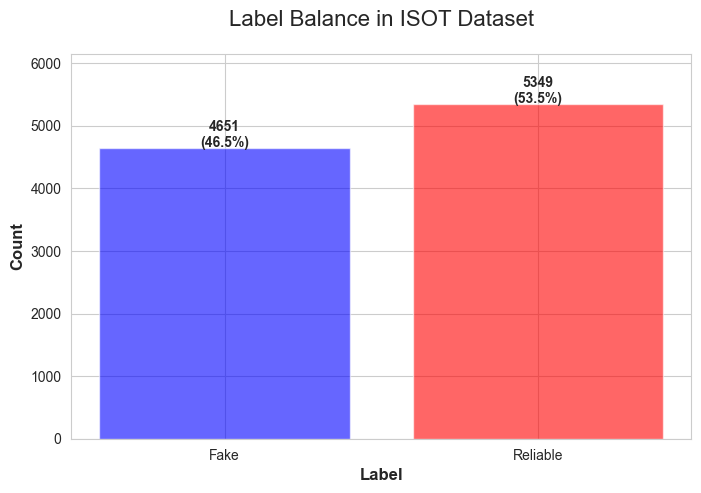

In [14]:
plot_label_distribution(df, dataset_name=dataset_name)

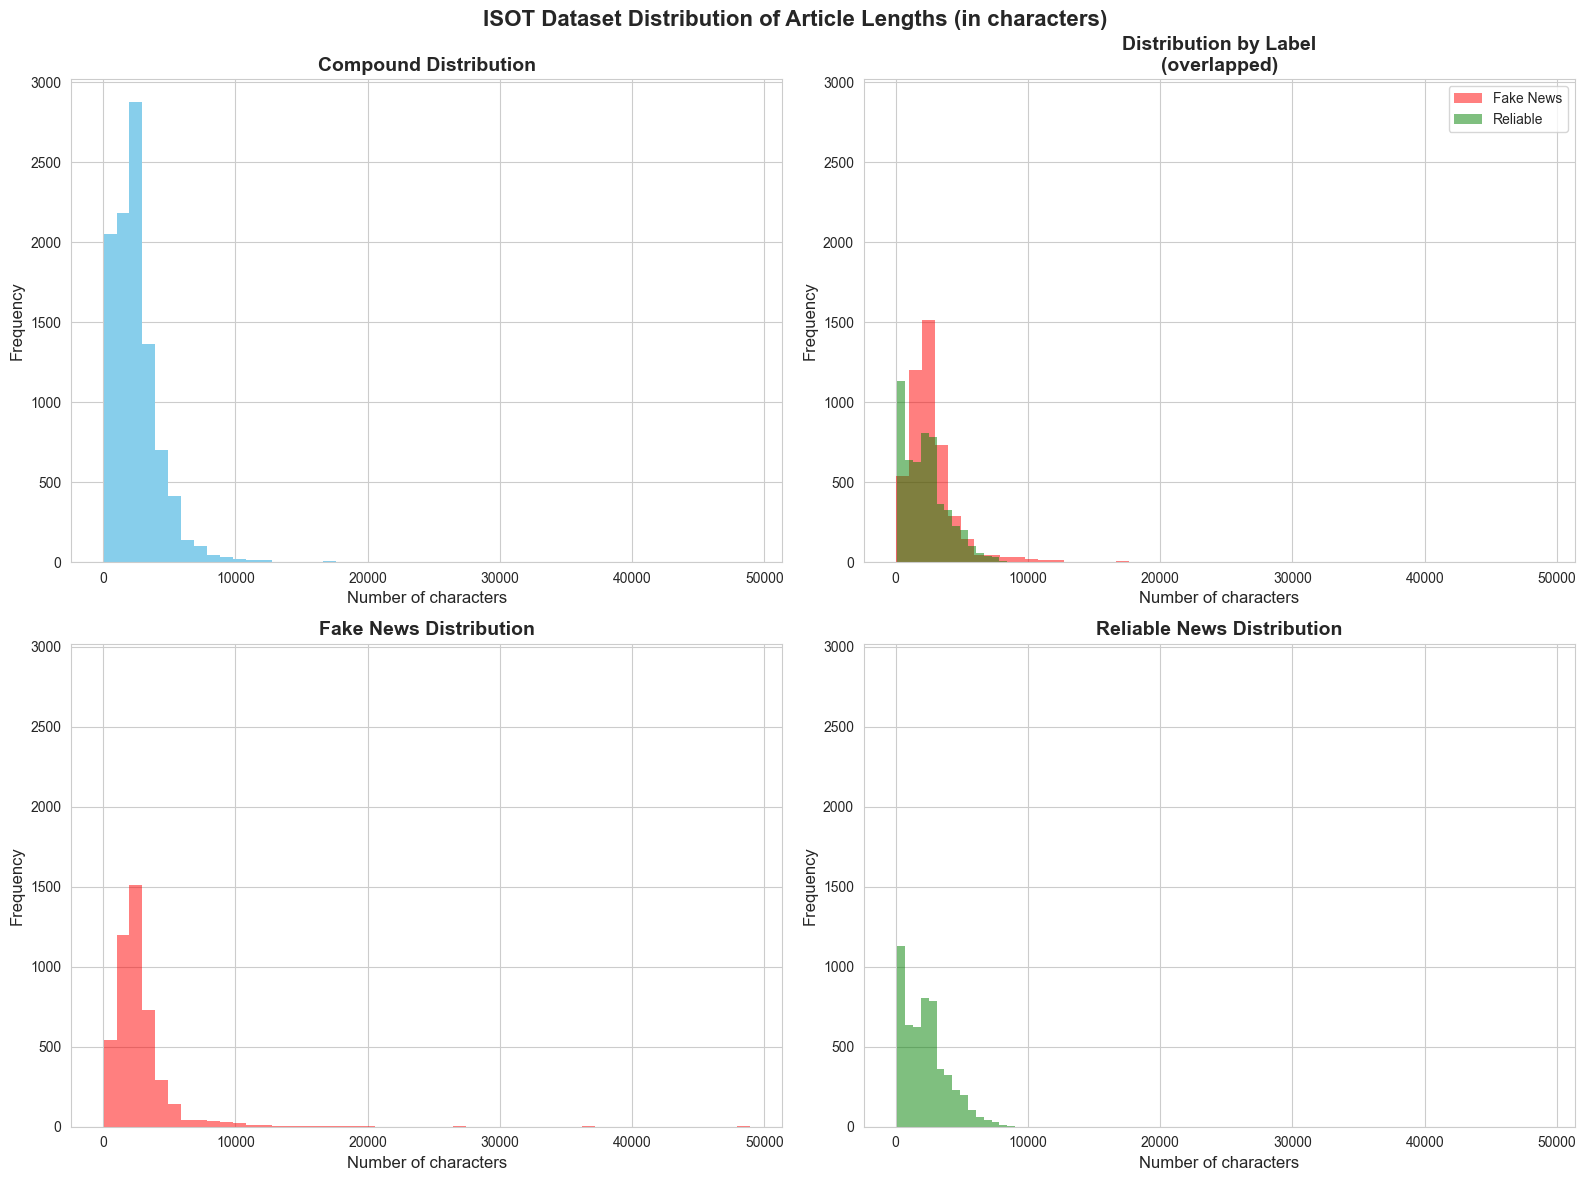

In [15]:
plot_article_length_distribution(df, dataset_name)

### Tokens Analysis


In [16]:
dataset = Dataset(dataset_name,
                  data_path=dataset_path).init(random_state=rd_seed)

2025-05-16 14:08:37,496 - Dataset - INFO - mlflow is not active, could not log the params: {'dataset_name': 'isot', 'train_pct': 0.7, 'val_pct': 0.15}
2025-05-16 14:08:37,497 - Dataset - INFO - mlflow is not active, could not log the params: {'dataset_signature': 'dataset(dn=isot,tp=0.7,vp=0.15);pipeline([])'}
2025-05-16 14:08:37,498 - Dataset - INFO - {'dataset_name': 'isot', 'train_pct': 0.7, 'val_pct': 0.15}
2025-05-16 14:08:37,499 - Dataset - INFO - mlflow is not active, could not log the params: {'preprocessing_pipeline_name': 'empty', 'preprocessing_pipeline_representation': "<PreprocessingPipeline 'empty': []>", 'preprocessing_pipeline': []}
2025-05-16 14:08:37,500 - Dataset - INFO - Prepared dataset does not exist, computing from scratch.
2025-05-16 14:08:37,977 - Dataset - INFO - Initializing preprocessing pipeline: <PreprocessingPipeline 'empty': []>
2025-05-16 14:08:37,978 - Dataset - INFO - artifacts path is none, skipping saving.


In [17]:
train_set_data = dataset.train_set
train_set_data.dataset.head()

,article,label
9069,New Study Proves That Trump Supporters Are Ra...,0
2603,Trump's legal team spokesman resigns amid repo...,1
7738,REVEALED: OOPS! Russian Ads Facebook’s Zuckerb...,0
1579,Catalan independence group calls for 'peaceful...,1
5058,Jailed Hong Kong democracy activists win last ...,1


#### NLTK tokenizer

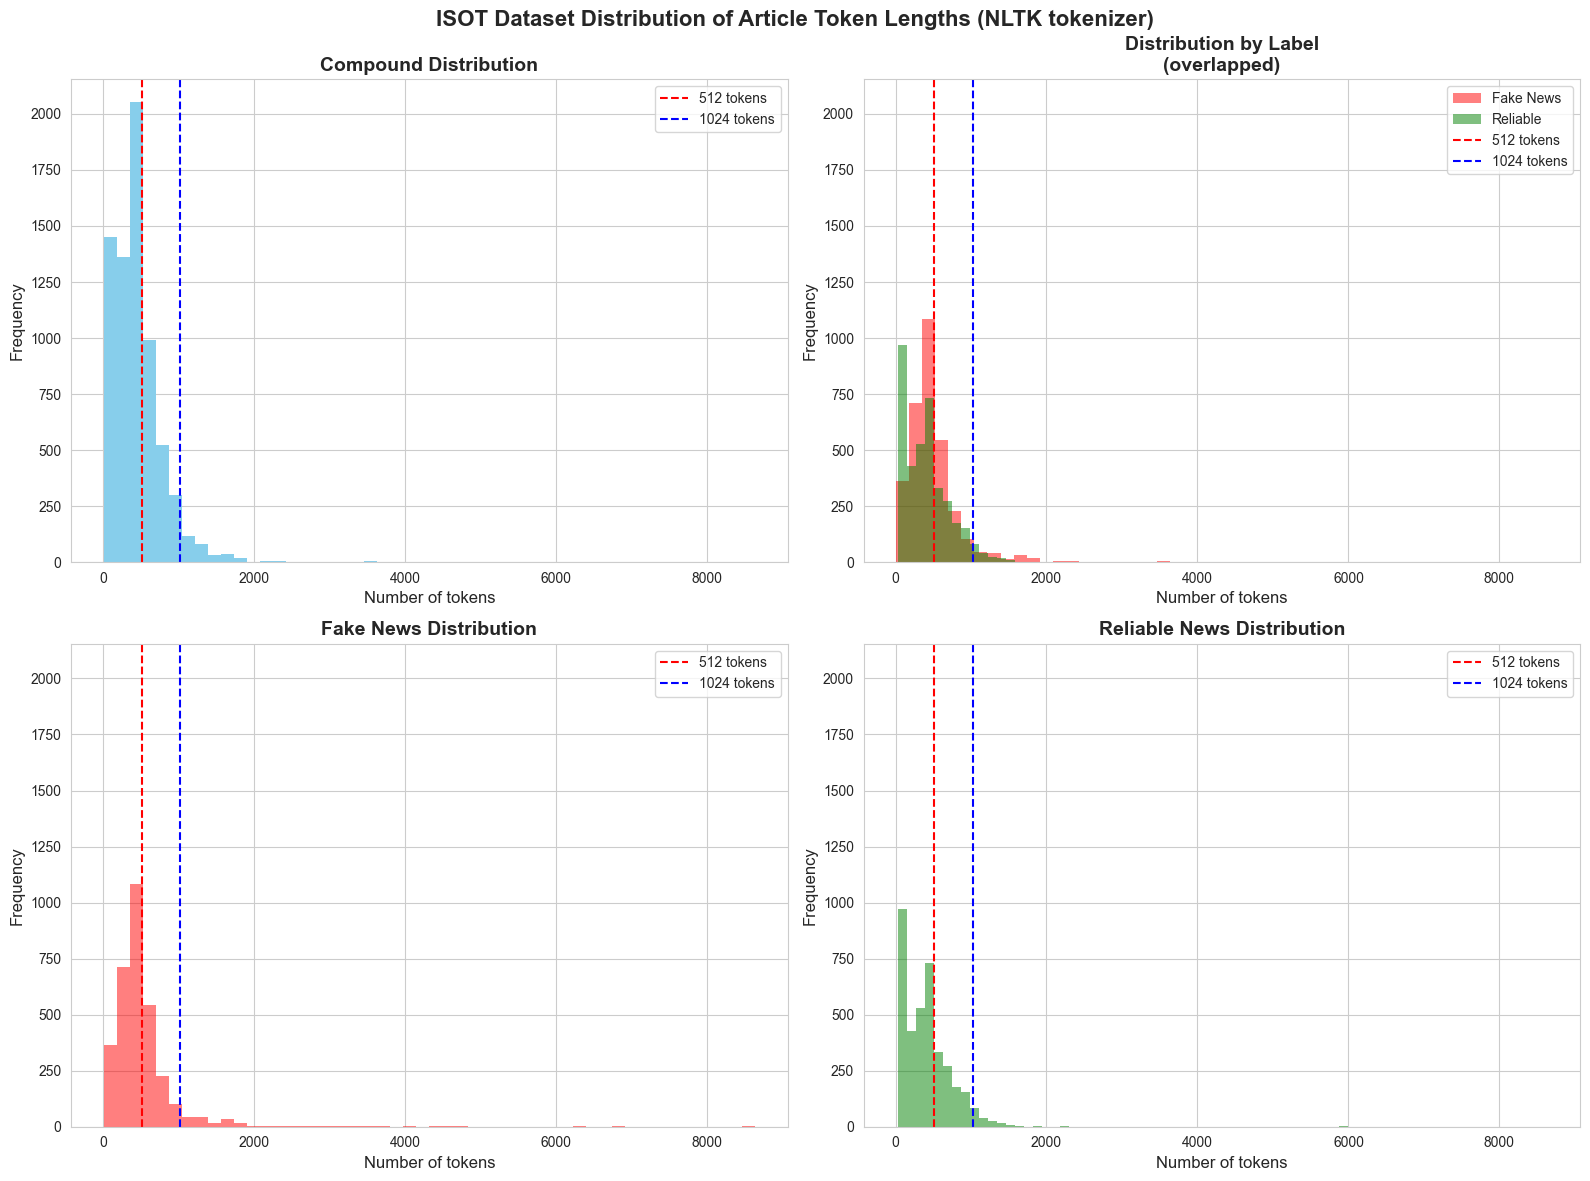

In [18]:
tokenizer = NLTKTokenizer(language='czech')
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='NLTK')

#### BERT Tokenizer

Token indices sequence length is longer than the specified maximum sequence length for this model (620 > 512). Running this sequence through the model will result in indexing errors


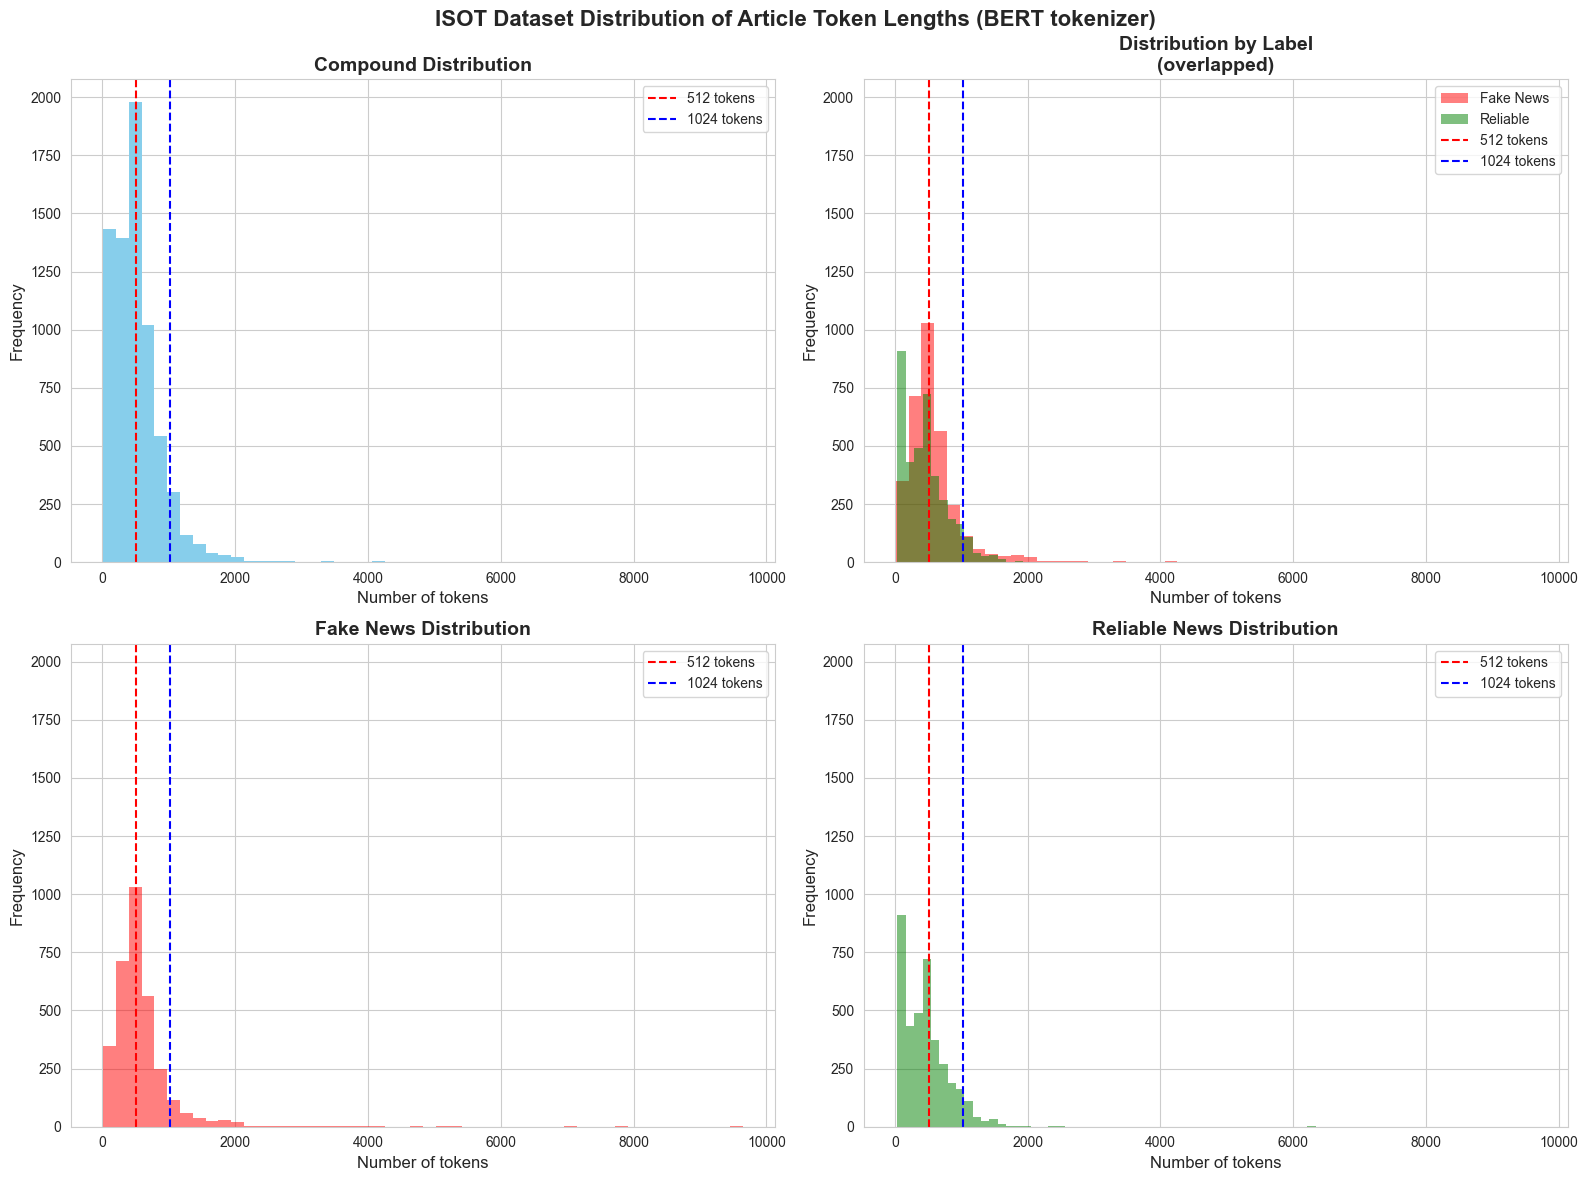

In [19]:
tokenizer = BERTTokenizer().init()
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='BERT')

#### GPT1 Tokenizer

Token indices sequence length is longer than the specified maximum sequence length for this model (629 > 512). Running this sequence through the model will result in indexing errors


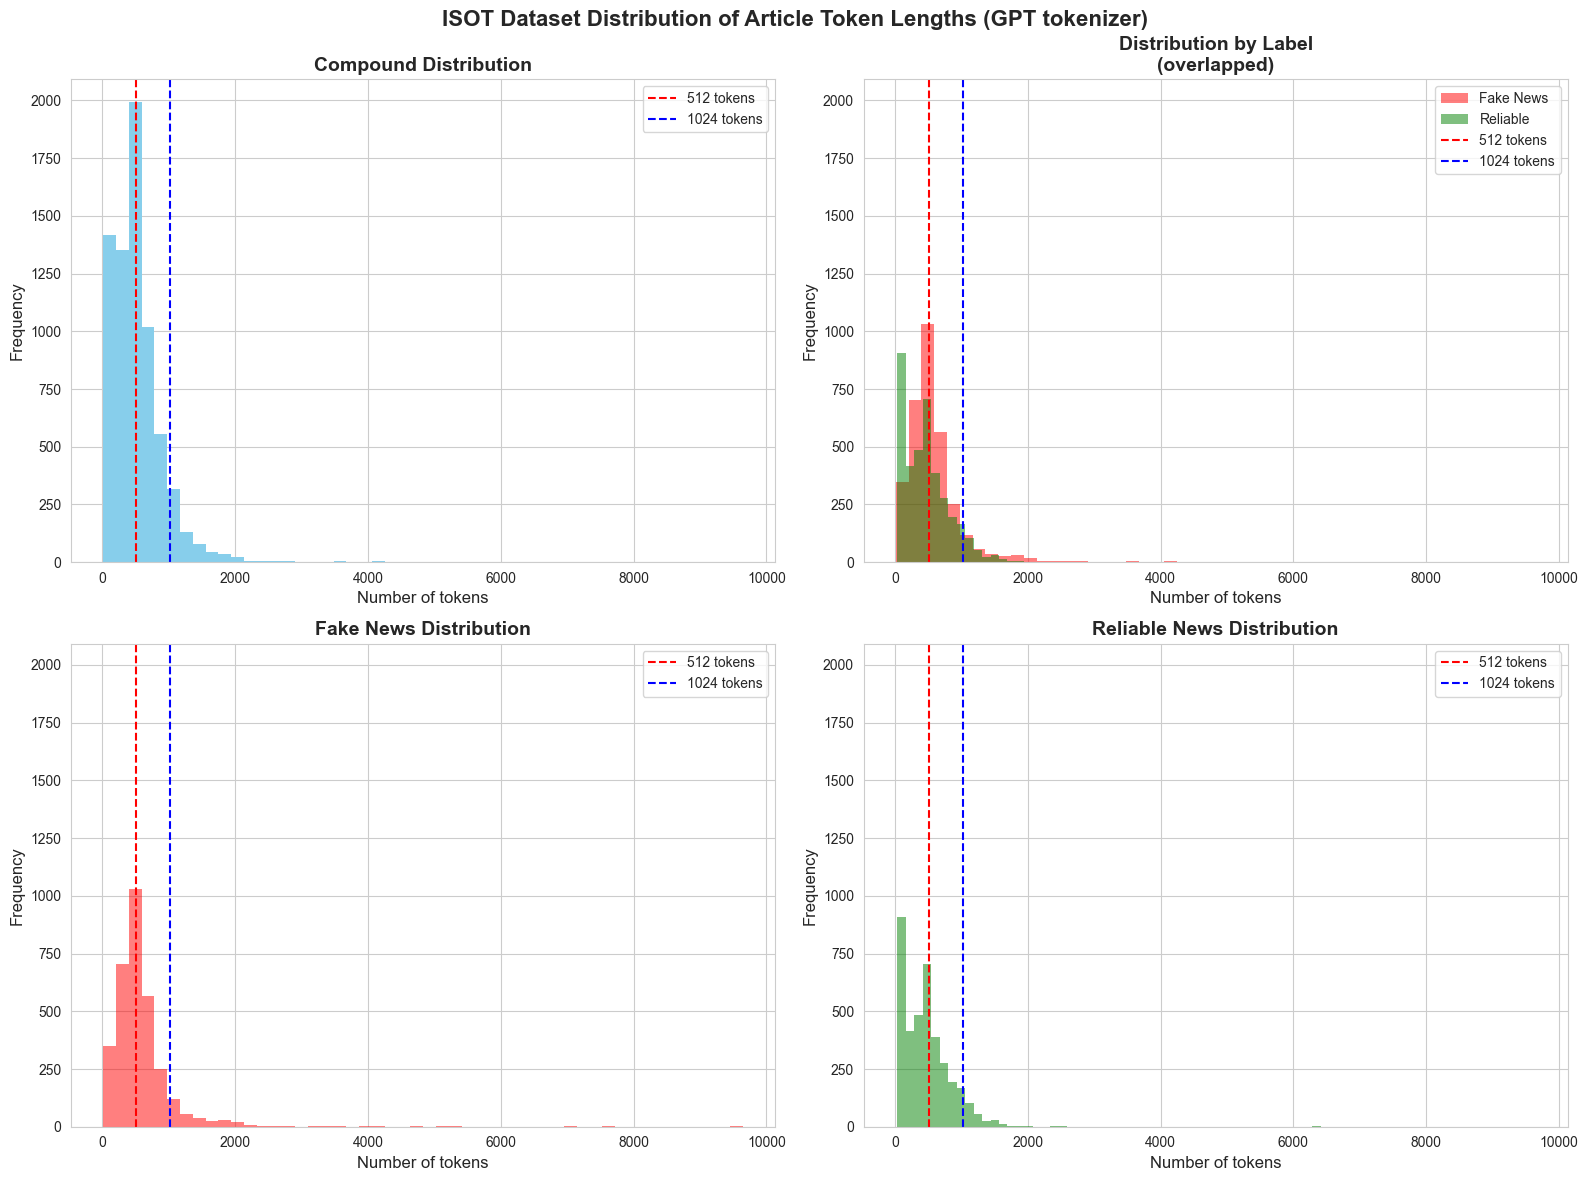

In [20]:
tokenizer = GPT1_Tokenizer().init()
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='GPT')